In [1]:
import sys
import os
import yaml

# Add the project root to the sys.path so we can import 'core'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

try:
    with open("../.cred/credentials.yaml", "r") as file:
        cred = yaml.safe_load(file)
    os.environ["HF_TOKEN"] = cred["HF_TOKEN"]
    os.environ["GOOGLE_API_KEY"] = cred["GOOGLE_API_KEY"]
except Exception as e:
    raise


import librosa
import numpy as np
import pandas as pd
from core.stt.stt_pipeline import STTEngine

# 1. Initialize the Engine (loads weights into VRAM)
print("Initializing STT Engine...")
engine = STTEngine(asr_model_size="base", language="es", device="cuda", compute_type="float16")  #large-v3-turbo

# 2. Create a fresh streaming session
session = engine.create_session()

vocabulary = "Glucofast, posología, insuficiencia renal moderada."

Initializing STT Engine...


In [9]:
# --- Configuration ---
TEST_AUDIO_PATH = "/media/edwardl.campbell/D/code/AmetsAI/data/audio/audio.wav"
NETWORK_CHUNK_SIZE = 2048# Simulating ~128ms network payloads

print(f"Loading and resampling: {TEST_AUDIO_PATH}")
# Ensure 16kHz mono for Silero/Whisper
audio_data, _ = librosa.load(TEST_AUDIO_PATH, sr=16000, mono=True)

# Convert the float32 numpy array into raw bytes (simulating WebSocket binary transfer)
raw_audio_bytes = audio_data.astype(np.float32).tobytes()

results = []
bytes_per_chunk = NETWORK_CHUNK_SIZE * 4 # 4 bytes per float32

print("Simulating WebSocket stream...")

# Feed the bytes into the session chunk by chunk
for i in range(0, len(raw_audio_bytes), bytes_per_chunk):
    byte_chunk = raw_audio_bytes[i : i + bytes_per_chunk]

    # This is the exact function your FastAPI server calls
    record = session.process_chunk(byte_chunk, initial_prompt=vocabulary)

    if record and record["type"] == "transcript":
        results.append(record)
        print(f"Captured: {record['text']}")

# Flush the remaining buffer at EOF (simulating connection close)
# In a real stream, you might want to expose a manual `session.flush()` method
# to force a transcription of the residual buffer if the user hangs up abruptly.

Loading and resampling: /media/edwardl.campbell/D/code/AmetsAI/data/audio/audio.wav
Simulating WebSocket stream...
Captured: Visita  de  seguimiento  con  la  octora  elenatorres.  Le  he  llevado  la  ficha  técnica  de  Glucofast  que  me  pidió  la  semana  pasada.  Hemos  estado  revisando  juntos  el  apartado  de  posología.  Le  he  subrayado  que,  según  la  ficha,  para  el  segmento  de  pacientes  con  insuficiencia  renal  moderada,  es  decir,  con  un  filtrado  entre  30  y  60,  la  indicación  de  la  marca  es  ajustar  a  25  mil  iramos  al  día.  Me  ha  confirmado  que  lo  tendrá  en  cuenta  para  sus  próximas  precriciones  en  esa  perfil.


In [3]:
# Flatten the records for Pandas
flat_data = []
for r in results:
    # This automatically strips double spaces and NBSP characters
    clean_text = " ".join(r["text"].split())

    flat_data.append({
        "Transcript": clean_text,
        "Duration (s)": r["metrics"]["audio_duration_s"],
        "Inference (ms)": r["metrics"]["inference_time_ms"],
        "RTF": r["metrics"]["rtf"],
        "End-Point Latency (ms)": r["metrics"]["endpoint_latency_ms"]
    })

df_metrics = pd.DataFrame(flat_data)

print("\n--- Pipeline Performance Summary ---")
display(df_metrics)

# Optional: Print aggregate statistics
print(f"\nAverage End-Point Latency: {df_metrics['End-Point Latency (ms)'].mean():.0f} ms")
print(f"Average RTF: {df_metrics['RTF'].mean():.4f}")


--- Pipeline Performance Summary ---


,Transcript,Duration (s),Inference (ms),RTF,End-Point Latency (ms)
0,Visita de seguimiento con la doctora Elena Tor...,28.61,15.0,0.0005,1043.0



Average End-Point Latency: 1043 ms
Average RTF: 0.0005


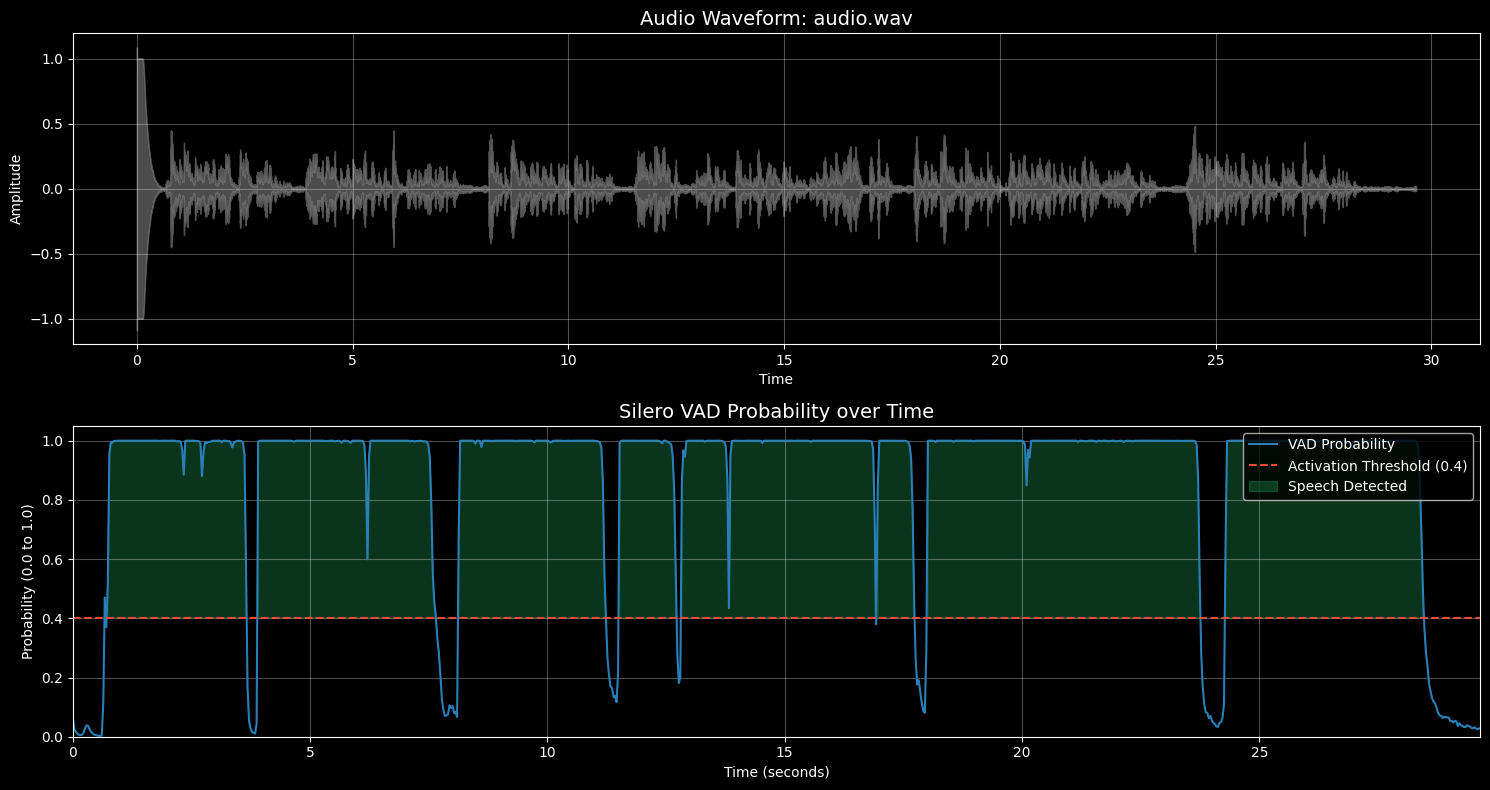

In [4]:
import matplotlib.pyplot as plt
import librosa.display
import torch
import numpy as np

# 1. Setup
vad_model = engine.vad_model
vad_model.reset_states() # Always reset before processing a new file
window_size = 512
sample_rate = 16000
vad_threshold = 0.4      # The threshold we want to visualize

audio, _ = librosa.load(TEST_AUDIO_PATH, sr=sample_rate, mono=True)

vad_probs = []
time_stamps = []

# 2. Extract VAD probabilities chunk-by-chunk
for i in range(0, len(audio), window_size):
    chunk = audio[i:i+window_size]

    # Pad the final chunk if it's too short
    if len(chunk) < window_size:
        chunk = np.pad(chunk, (0, window_size - len(chunk)))

    tensor_chunk = torch.from_numpy(chunk).float()

    with torch.no_grad():
        prob = vad_model(tensor_chunk, sample_rate).item()

    vad_probs.append(prob)
    # Record the time at the *start* of the chunk
    time_stamps.append(i / sample_rate)

# 3. Visualization
plt.figure(figsize=(15, 8))

# --- Top Plot: Raw Audio Waveform ---
plt.subplot(2, 1, 1)
librosa.display.waveshow(audio, sr=sample_rate, alpha=0.6, color='gray')
plt.title(f'Audio Waveform: {TEST_AUDIO_PATH.split("/")[-1]}', fontsize=14)
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# --- Bottom Plot: Silero VAD Probabilities ---
plt.subplot(2, 1, 2)
plt.plot(time_stamps, vad_probs, label='VAD Probability', color='#2980b9', linewidth=1.5)

# Draw the VAD activation threshold
plt.axhline(y=vad_threshold, color='#e74c3c', linestyle='--', label=f'Activation Threshold ({vad_threshold})')

# Highlight regions where the VAD considers the user to be speaking
plt.fill_between(
    time_stamps,
    vad_probs,
    vad_threshold,
    where=(np.array(vad_probs) > vad_threshold),
    alpha=0.3,
    color='#27ae60',
    label='Speech Detected'
)

plt.title('Silero VAD Probability over Time', fontsize=14)
plt.xlabel('Time (seconds)')
plt.ylabel('Probability (0.0 to 1.0)')
plt.ylim(0, 1.05)
plt.xlim(0, len(audio) / sample_rate)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
